In [2]:
# Instalar dependências necessárias
!pip install datasets pillow requests scikit-learn matplotlib seaborn


In [3]:
import requests
import time
import io
from PIL import Image
import numpy as np
from datasets import load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações
SERVICE_URL = "http://localhost:8003"
SAMPLE_SIZE = 100  # Número de amostras a testar

# Mapeamento de emoções FER-2013 -> DeepFace
emotion_mapping = {
    0: "angry",
    1: "disgust", 
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

print(f"🎯 Configuração:")
print(f"   Serviço: {SERVICE_URL}")
print(f"   Amostras: {SAMPLE_SIZE}")


/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🎯 Configuração:
   Serviço: http://localhost:8003
   Amostras: 100


In [4]:
# Verificar se o serviço está rodando
def check_service():
    try:
        response = requests.get(f"{SERVICE_URL}/health", timeout=5)
        if response.status_code == 200:
            print("✅ Serviço está rodando")
            return True
        else:
            print(f"❌ Serviço retornou status: {response.status_code}")
            return False
    except:
        print("❌ Serviço não está disponível")
        print("💡 Execute: docker compose -f docker-compose.dev.yml up emotion-service -d")
        return False

check_service()


✅ Serviço está rodando


True

## Load FER-2013

In [20]:
from datasets import load_dataset
import numpy as np
from PIL import Image
import io

print("📥 Carregando dataset FER-2013...")
dataset = load_dataset("raf-db", split="test", trust_remote_code=True)
print("✅ RAF-DB carregado")
SAMPLE_SIZE = 100

sample_indices = [int(i) for i in np.random.choice(len(dataset), min(SAMPLE_SIZE, len(dataset)), replace=False)]
samples = [dataset[i] for i in sample_indices]

print(f"✅ Carregadas {len(samples)} amostras do FER-2013")
print(f"📊 Primeiro exemplo: {samples[0]['labels']}")

# img = Image.open(io.BytesIO(samples[0]["img_bytes"]))
# img.show()


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'raf-db' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


📥 Carregando dataset FER-2013...


DatasetNotFoundError: Dataset 'raf-db' doesn't exist on the Hub or cannot be accessed.

### Load JAFFE

In [36]:
import os
from PIL import Image
import pandas as pd

# Mapas dos códigos para emoções
label_map = {
    'AN': 'anger', 'DI': 'disgust', 'FE': 'fear', 'HA': 'happy',
    'SA': 'sad', 'SU': 'surprise', 'NE': 'neutral'
}

img_dir = './assets/jaffe/jaffe'  # Pasta onde extraiu o dataset
imgs, labels = [], []

for fname in os.listdir(img_dir):
    if fname.lower().endswith('.tiff'):
        label_code = fname.split('.')[1][:2].upper()  # Ex: 'KA.HA1.31.tiff' -> 'HA'
        if label_code in label_map:
            img = Image.open(os.path.join(img_dir, fname)).convert('L').resize((224,224))
            imgs.append(img)
            labels.append(label_map[label_code])

# Crie um DataFrame para manipulação fácil
df_jaffe = pd.DataFrame({'image': imgs, 'emotion_label': labels})

print(f"✅ JAFFE carregado: {len(df_jaffe)} imagens")
print("📊 Rótulos:", df_jaffe['emotion_label'].value_counts())

✅ JAFFE carregado: 213 imagens
📊 Rótulos: emotion_label
fear        32
sad         31
happy       31
anger       30
surprise    30
neutral     30
disgust     29
Name: count, dtype: int64


In [37]:
# Função para predizer emoção
def predict_emotion(image):
    # Converter imagem para bytes
    img_buffer = io.BytesIO()
    image.save(img_buffer, format='JPEG')
    img_bytes = img_buffer.getvalue()
    
    # Fazer requisição
    files = {"file": ("test.jpg", img_bytes, "image/jpeg")}
    
    start_time = time.time()
    response = requests.post(f"{SERVICE_URL}/analyze-facial-expression", files=files, timeout=10)
    end_time = time.time()
    
    response_time = (end_time - start_time) * 1000  # em ms
    
    if response.status_code == 200:
        data = response.json()
        emotion = data.get("dominant_emotion", "neutral")
        confidence = data.get("confidence", 0.0)
        return emotion, confidence, response_time
    else:
        return "neutral", 0.0, response_time

print("✅ Função de predição criada")


✅ Função de predição criada


In [44]:
## Predic JAFFE

print("🧪 Iniciando teste de acurácia no JAFFE...")

true_labels = []
predicted_labels = []
response_times = []
confidences = []

for i, row in df_jaffe.iterrows():
    image = row['image'].convert('RGB')  # JAFFE já vem 224x224 acima
    true_emotion = row['emotion_label']

    pred_emotion, confidence, response_time = predict_emotion(image)

    true_labels.append(true_emotion)
    predicted_labels.append(pred_emotion)
    response_times.append(response_time)
    confidences.append(confidence)
    
    correct = "✅" if pred_emotion == true_emotion else "❌"
    print(f"{i+1:3d}/{len(df_jaffe)}: {true_emotion:8s} → {pred_emotion:8s} {correct} (conf: {confidence:.2f}, {response_time:.0f}ms)")

print("\n✅ Teste concluído no JAFFE!")

🧪 Iniciando teste de acurácia no JAFFE...
  1/213: sad      → sad      ✅ (conf: 0.75, 4233ms)
  2/213: disgust  → neutral  ❌ (conf: 0.48, 4136ms)


KeyboardInterrupt: 

In [28]:
## Predict FER-2013

# for i, sample in enumerate(samples):
#     # Extrair imagem (img_bytes → PIL.Image)
#     if isinstance(sample['img_bytes'], bytes):
#         image = Image.open(io.BytesIO(sample['img_bytes']))
#     else:
#         image = sample['image']   # Caso já seja PIL.Image

#     # Pega o rótulo verdadeiro
#     true_emotion_id = sample['emotion_label']
#     true_emotion = emotion_mapping[true_emotion_id]
    
#     # Redimensionar para 224x224
#     image = image.convert('RGB').resize((224, 224))
    
#     # Predizer emoção
#     pred_emotion, confidence, response_time = predict_emotion(image)
    
#     # Armazenar resultados
#     true_labels.append(true_emotion)
#     predicted_labels.append(pred_emotion)
#     response_times.append(response_time)
#     confidences.append(confidence)
    
#     # Status
#     correct = "✅" if pred_emotion == true_emotion else "❌"
#     print(f"{i+1:3d}/{len(samples)}: {true_emotion:8s} → {pred_emotion:8s} {correct} (conf: {confidence:.2f}, {response_time:.0f}ms)")


In [43]:
# Calcular métricas
accuracy = accuracy_score(true_labels, predicted_labels)
avg_response_time = np.mean(response_times)
p95_response_time = np.percentile(response_times, 95)
avg_confidence = np.mean(confidences)

print("\n" + "="*60)
print("📊 RESULTADOS FINAIS")
print("="*60)
print(f"🎯 Acurácia: {accuracy:.3f} ({accuracy*100:.1f}%)")
print(f"⚡ Tempo médio: {avg_response_time:.1f}ms")
print(f"📈 P95 tempo: {p95_response_time:.1f}ms")
print(f"🎭 Confiança média: {avg_confidence:.3f}")
print(f"📊 Amostras testadas: {len(df_jaffe)}")
print(f"✅ Predições corretas: {sum(1 for t, p in zip(true_labels, predicted_labels) if t == p)}")
print(f"🚀 Throughput: ~{1000/avg_response_time:.1f} req/s")



📊 RESULTADOS FINAIS
🎯 Acurácia: 0.141 (14.1%)
⚡ Tempo médio: 16.5ms
📈 P95 tempo: 22.0ms
🎭 Confiança média: 0.850
📊 Amostras testadas: 213
✅ Predições corretas: 30
🚀 Throughput: ~60.5 req/s


In [40]:
# Relatório detalhado por emoção
print("\n📈 RELATÓRIO POR EMOÇÃO:")
print(classification_report(true_labels, predicted_labels, digits=3))



📈 RELATÓRIO POR EMOÇÃO:
              precision    recall  f1-score   support

       anger      0.000     0.000     0.000        30
       angry      0.000     0.000     0.000         0
     disgust      0.000     0.000     0.000        29
        fear      0.379     0.344     0.361        32
       happy      0.821     0.742     0.780        31
     neutral      0.333     0.567     0.420        30
         sad      0.244     0.677     0.359        31
    surprise      0.933     0.467     0.622        30

    accuracy                          0.404       213
   macro avg      0.339     0.350     0.318       213
weighted avg      0.390     0.404     0.367       213



/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/toni/projects/empath-ia/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

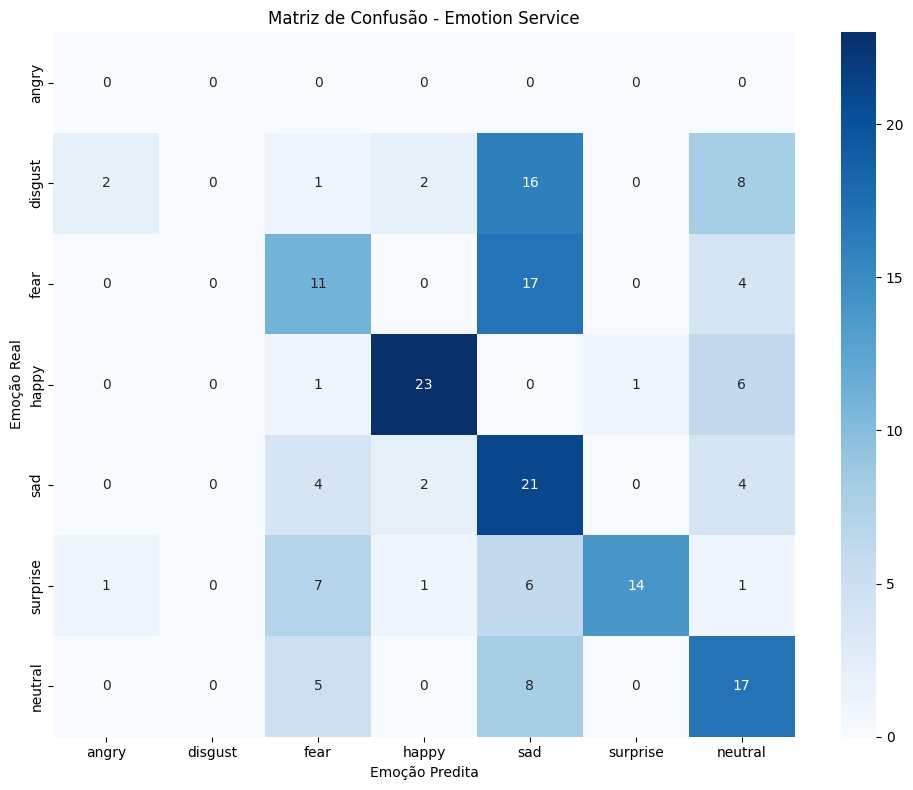

In [41]:
# Matriz de confusão
emotions = list(emotion_mapping.values())
cm = confusion_matrix(true_labels, predicted_labels, labels=emotions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=emotions, yticklabels=emotions)
plt.title('Matriz de Confusão - Emotion Service')
plt.xlabel('Emoção Predita')
plt.ylabel('Emoção Real')
plt.tight_layout()
plt.show()


In [ ]:
# Gráfico de tempos de resposta
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(response_times, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(avg_response_time, color='red', linestyle='--', label=f'Média: {avg_response_time:.1f}ms')
plt.axvline(p95_response_time, color='orange', linestyle='--', label=f'P95: {p95_response_time:.1f}ms')
plt.xlabel('Tempo de Resposta (ms)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Tempos de Resposta')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(response_times)
plt.ylabel('Tempo de Resposta (ms)')
plt.title('Box Plot - Tempos de Resposta')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Estatísticas de performance detalhadas
print("\n📊 ESTATÍSTICAS DE PERFORMANCE:")
print(f"   Tempo Médio: {np.mean(response_times):.1f}ms")
print(f"   Tempo Mediano: {np.median(response_times):.1f}ms")
print(f"   Desvio Padrão: {np.std(response_times):.1f}ms")
print(f"   Tempo Mínimo: {np.min(response_times):.1f}ms")
print(f"   Tempo Máximo: {np.max(response_times):.1f}ms")
print(f"   P90: {np.percentile(response_times, 90):.1f}ms")
print(f"   P95: {np.percentile(response_times, 95):.1f}ms")
print(f"   P99: {np.percentile(response_times, 99):.1f}ms")

print("\n🎯 ANÁLISE FINAL:")
if accuracy >= 0.6:
    print("   ✅ Acurácia excelente para produção")
elif accuracy >= 0.4:
    print("   🟡 Acurácia moderada - considerar melhorias")
else:
    print("   🔴 Acurácia baixa - verificar configurações do modelo")

if avg_response_time <= 100:
    print("   ⚡ Performance excelente para tempo real")
elif avg_response_time <= 500:
    print("   ✅ Performance adequada para tempo real")
else:
    print("   ⚠️ Performance pode ser otimizada")

print(f"\n🎉 Teste completo finalizado!")
